# Data Visualization Week - Day 1: Foundations & Real-World Application

## Week 4, Day 1 - From Theory to Practice

---

### Today's Journey (2.5 Hours)

| Part | Topic | Duration |
|------|-------|---------|
| 1 | Quick Review & Chart Selection | ~15 min |
| 2 | Meet the Penguins: Real Data Exploration | ~20 min |
| | **BREAK 1** | 10 min |
| 3 | Histograms: Understanding Distributions | ~25 min |
| 4 | Categorical Comparisons: Bar Plots & Count Plots | ~30 min |
| | **BREAK 2** | 10 min |
| 5 | Scatter Plots & Relationships | ~25 min |
| 6 | Pair Plots: Seeing Everything at Once | ~20 min |
| 7 | Mini-Project: Penguin Research Dashboard | ~25 min |

---

```
THIS WEEK'S PROMISE:

    ┌─────────────────────────────────────────────────────────────────────┐
    │                                                                     │
    │   Last week, you learned the TOOLS:                               │
    │   - plt.plot(), plt.bar(), sns.histplot()                         │
    │   - Basic customization                                            │
    │   - How to read different chart types                             │
    │                                                                     │
    │   This week, you master the CRAFT:                                │
    │   - Choosing the RIGHT chart for each question                    │
    │   - Handling messy, real-world data                               │
    │   - Creating publication-quality visualizations                   │
    │   - Building complete analytical dashboards                       │
    │                                                                     │
    │   By Friday, you'll create visualizations that make              │
    │   stakeholders say "I never saw that pattern before."            │
    │                                                                     │
    └─────────────────────────────────────────────────────────────────────┘
```

## Setup - Run This First!

**IMPORTANT: Run this cell before anything else.**

In [ ]:
# ============================================
# RUN THIS CELL FIRST - All imports for today
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Set default figure size
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries loaded! Ready for visualization.")

All libraries loaded! Ready for visualization.


---

# Part 1: Quick Review - Chart Selection

## The Foundation We Built Last Week

---

## Chart Selection Quick Reference

```
WHICH CHART FOR WHICH QUESTION?

    ┌──────────────────────────────────────────────────────────────────────┐
    │ YOUR QUESTION                     │ USE THIS CHART                   │
    ├───────────────────────────────────┼──────────────────────────────────┤
    │ "How is X distributed?"           │ Histogram, KDE                   │
    │ "How many in each category?"      │ Count plot, Bar plot             │
    │ "How do groups compare on Y?"     │ Bar plot (means), Box plot       │
    │ "How do X and Y relate?"          │ Scatter plot                     │
    │ "How does Y change over time?"    │ Line plot                        │
    │ "How do distributions differ?"    │ Box plot, Violin plot            │
    │ "What are ALL the relationships?" │ Pair plot                        │
    │ "What correlates with what?"      │ Heatmap                          │
    └───────────────────────────────────┴──────────────────────────────────┘

    THE KEY INSIGHT:
    
    Start with the QUESTION, not the chart.
    "I want to make a bar chart" → WRONG approach
    "I want to compare average weight across species" → RIGHT approach
        → Then you realize: bar chart or box plot would work
```

## The Power of 'hue' - Quick Reminder

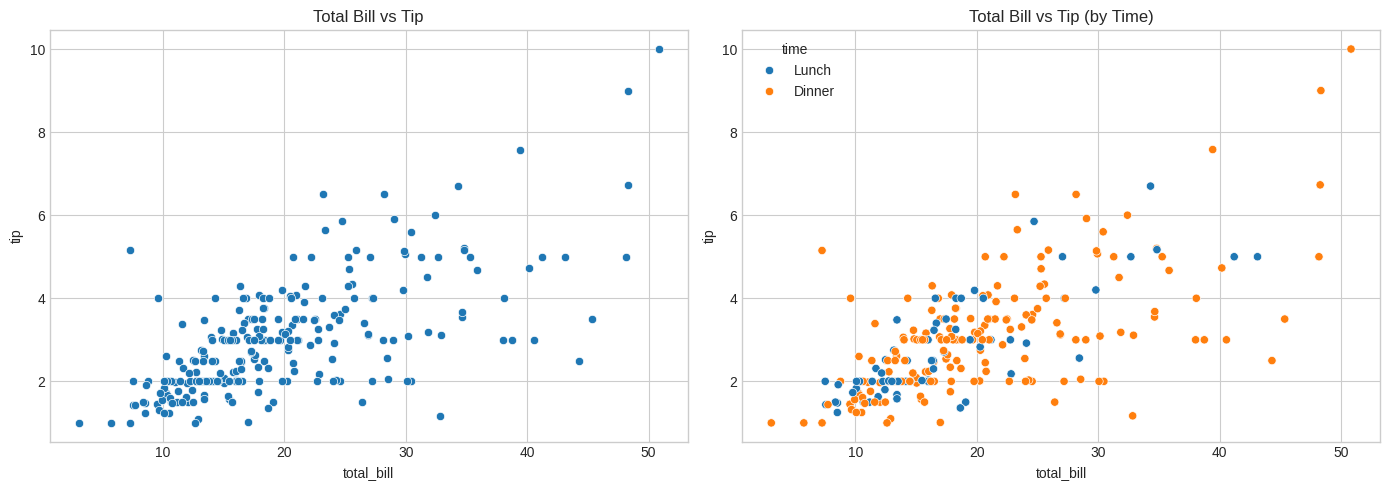

One parameter - hue='time' - reveals the lunch vs dinner pattern!


In [ ]:
# Quick demo: The magic of hue
tips = sns.load_dataset('tips')

# Create side-by-side comparison: without hue vs with hue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Basic scatter
sns.scatterplot(data=tips, x='total_bill', y='tip', ax=axes[0])
axes[0].set_title('Total Bill vs Tip')

# RIGHT: Same scatter but with hue='time'
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', ax=axes[1])
axes[1].set_title('Total Bill vs Tip (by Time)')

plt.tight_layout()
plt.show()

print("One parameter - hue='time' - reveals the lunch vs dinner pattern!")

---

# Part 2: Meet the Penguins

## Real Data from Antarctic Research

---

In [ ]:
# Load the Palmer Penguins dataset
penguins = sns.load_dataset('penguins')

print(f"Dataset: {penguins.shape[0]} penguins, {penguins.shape[1]} variables")
print(f"Columns: {list(penguins.columns)}")

Dataset: 344 penguins, 7 variables
Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


In [ ]:
penguins['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [ ]:
penguins['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [ ]:
# First look at the data
penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [ ]:
# ===========================================
# LIVE CODING: Explore the data
# ===========================================
# Check species distribution with value_counts()
# Check island distribution
# Check sex distribution

penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
# Check for missing values
print("Missing values by column:")
print(penguins.isnull().sum())

print(f"\nRows with any missing: {penguins.isnull().any(axis=1).sum()}")

Missing values by column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Rows with any missing: 11


In [ ]:
# ===========================================
# LIVE CODING: Clean the data
# ===========================================
# Drop rows with missing values using dropna()
# Print before and after counts
penguins_clean = penguins.dropna()    #los eimina sin mas porque solo vamos a hacer visualizaciones, pero no es lo recomendable



print('Before', len(penguins))
print('After', len(penguins_clean))

difference = len(penguins) - len(penguins_clean)
percentage = difference / len(penguins) * 100

print(f'diference: {difference} rows, {percentage:.2f} %')

Before 344
After 333
diference: 11 rows, 3.20 %


---

## BREAK 1 (10 Minutes)

### What we've covered:
- Chart selection framework: question first, then chart
- The power of 'hue' for comparisons
- Loaded and explored the Palmer Penguins dataset
- Handled missing values

### Coming up after break:
- **Histograms** - Understanding how values are distributed
- Comparing distributions across groups

---

---

# Part 3: Histograms - Understanding Distributions

## "How Is This Variable Spread Out?"

---

## Basic Histogram: Body Mass Distribution

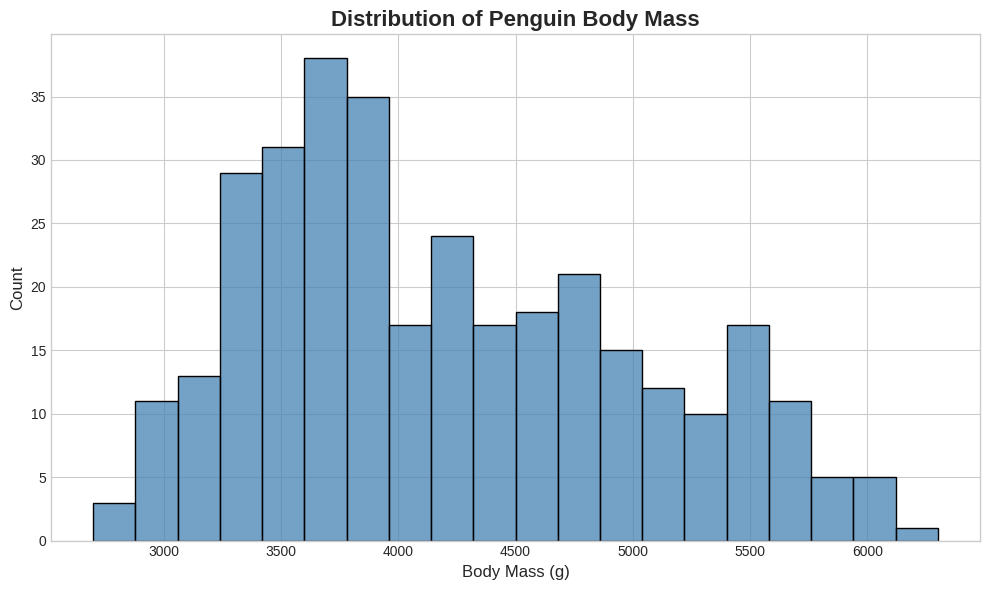

In [ ]:
# ===========================================
# LIVE CODING: Basic Histogram
# ===========================================
# Create a histogram with:
#   - plt.figure(figsize=(10, 6))
#   - sns.histplot(data=penguins_clean, x='body_mass_g', bins=20)
#   - plt.title('...')
#   - plt.xlabel('...')
#   - plt.ylabel('...')
#   - plt.show()

plt.figure(figsize=(10, 6))

sns.histplot(data=penguins_clean, x='body_mass_g', bins=20, color='steelblue')
plt.title("Distribution of Penguin Body Mass", fontsize=16, fontweight='bold')
plt.xlabel("Body Mass (g)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

# bimodal - bi(two) + modal(peaks)

## Adding KDE for Smoother Visualization

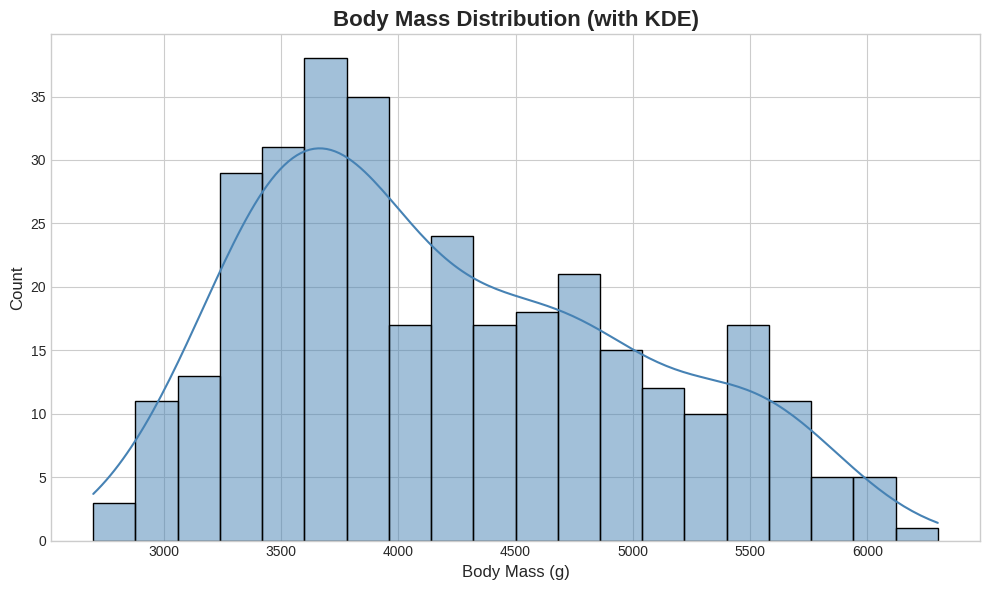

Notice the TWO PEAKS - this is called a bimodal distribution!
Why might there be two peaks? Let's find out...


In [ ]:
# Add KDE (Kernel Density Estimate) to see the shape more clearly
plt.figure(figsize=(10, 6))

sns.histplot(data=penguins_clean, x='body_mass_g', bins=20, kde=True, color='steelblue')

plt.title('Body Mass Distribution (with KDE)', fontsize=16, fontweight='bold')
plt.xlabel('Body Mass (g)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

print("Notice the TWO PEAKS - this is called a bimodal distribution!")
print("Why might there be two peaks? Let's find out...")

## The Reveal: Using 'hue' to Compare Species

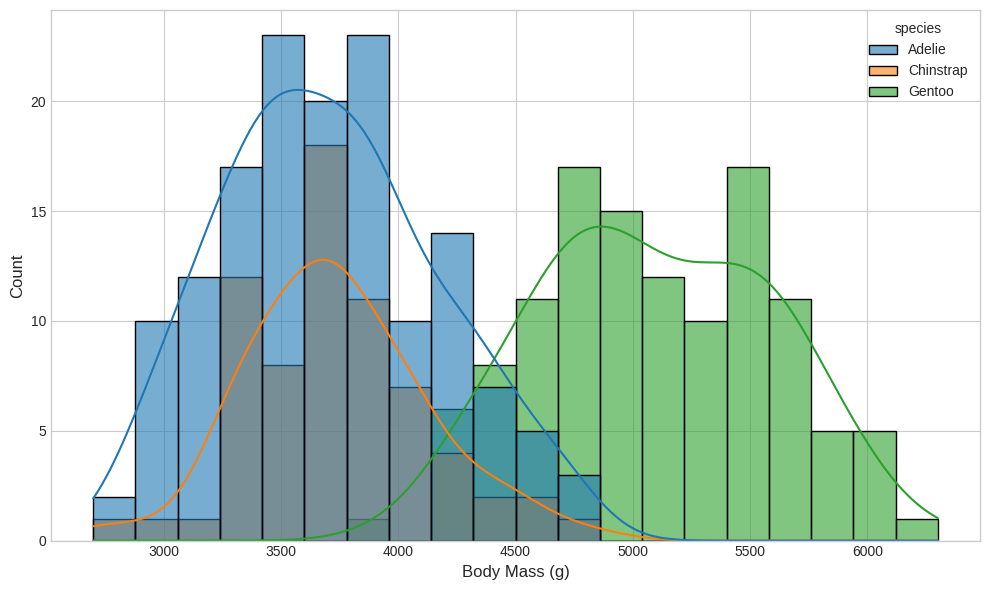

In [ ]:
# ===========================================
# LIVE CODING: Add hue by species - # stratify
# ===========================================
# Reveal the mystery! Add hue='species' to see what's causing the two peaks
#   - plt.figure(figsize=(10, 6))
#   - sns.histplot(data=penguins_clean, x='body_mass_g', hue='species', bins=20, alpha=0.6, kde=True)
#   - plt.title('Body Mass Distribution by Species')
#   - plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(data=penguins_clean, x='body_mass_g', hue='species', bins=20, alpha=0.6, kde=True)
plt.xlabel('Body Mass (g)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()


## Histogram Variations: Layered vs Dodged

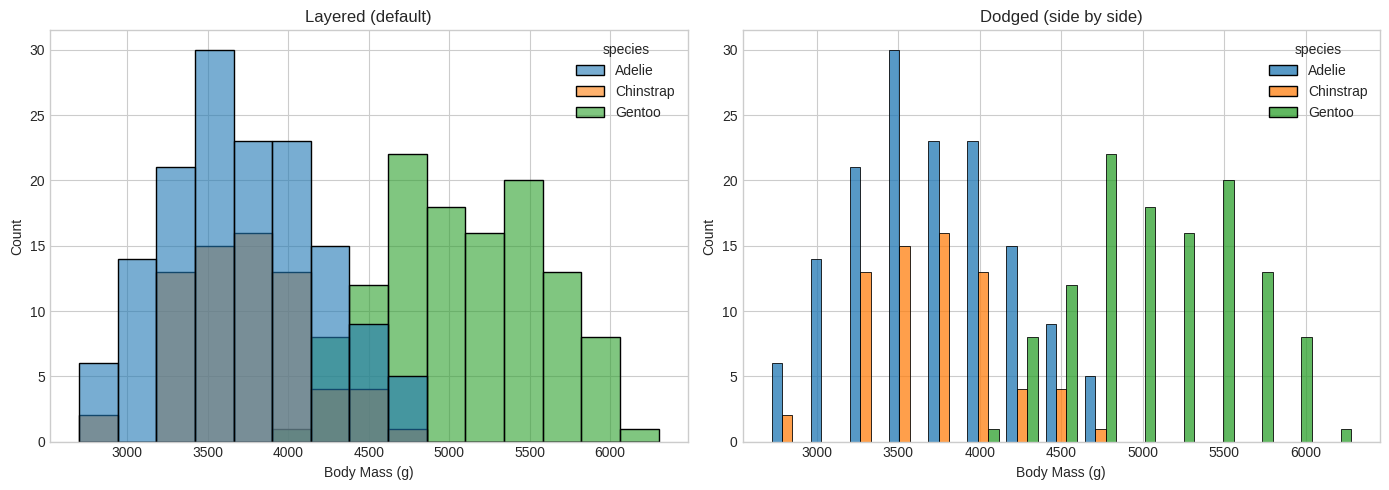

In [ ]:
# Histogram variations: Layered vs Dodged
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Layered (default) - good for seeing overlap
sns.histplot(data=penguins_clean, x='body_mass_g', hue='species',
             bins=15, alpha=0.6, ax=axes[0])
axes[0].set_title('Layered (default)')
axes[0].set_xlabel('Body Mass (g)')

# RIGHT: Dodged - side by side for direct comparison
sns.histplot(data=penguins_clean, x='body_mass_g', hue='species',
             bins=15, multiple='dodge', shrink=0.8, ax=axes[1])
axes[1].set_title('Dodged (side by side)')
axes[1].set_xlabel('Body Mass (g)')

plt.tight_layout()
plt.show()

## Quick Practice: Histograms (3 minutes)

**Your turn!** Create a histogram of `bill_length_mm` with `hue` by `sex`.

Question to answer: Do male and female penguins have different bill lengths?

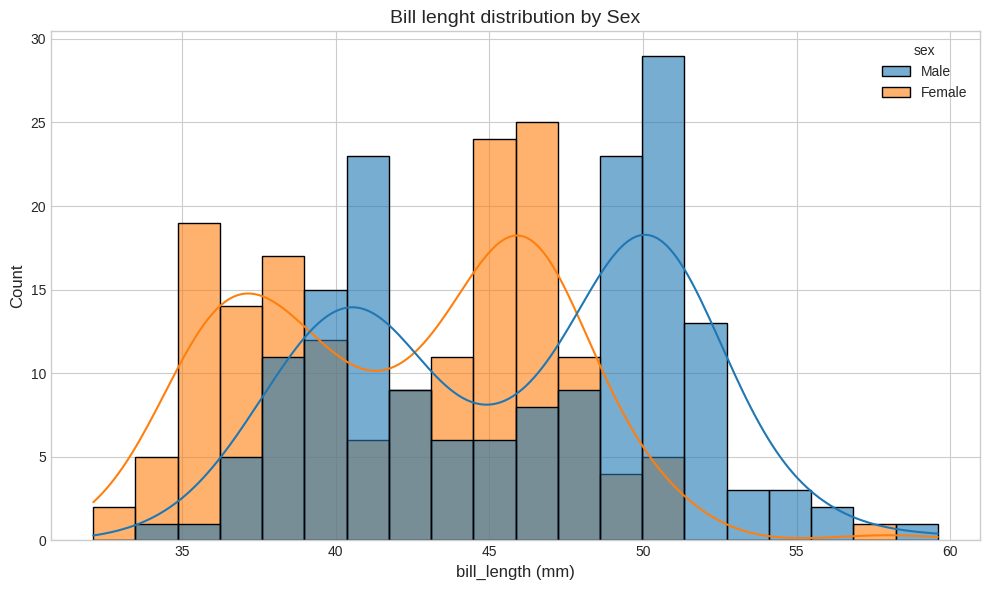

Males tend to have slightly longer bills, but there's a lot of overlap.


In [ ]:
# YOUR CODE HERE
# Create a histogram of bill_length_mm with hue='sex'

plt.figure(figsize=(10, 6))
sns.histplot(data=penguins_clean, x='bill_length_mm', hue='sex', bins=20, alpha=0.6, kde=True)
plt.title('Bill lenght distribution by Sex', fontsize=14, )
plt.xlabel('bill_length (mm)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()
print("Males tend to have slightly longer bills, but there's a lot of overlap.")

---

# Part 4: Categorical Comparisons - Bar Plots & Count Plots

## "How Do Groups Compare?"

---

```
TWO TYPES OF CATEGORICAL CHARTS:

    COUNT PLOT - "How many in each category?"
    → Just counting occurrences
    → Example: How many penguins of each species?

    BAR PLOT - "What's the average for each category?"
    → Calculates and displays a statistic (usually mean)
    → Example: What's the average weight of each species?
```

## Count Plot: How Many of Each?

/tmp/ipython-input-2166719847.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=penguins_clean, x='species', palette='Set2')


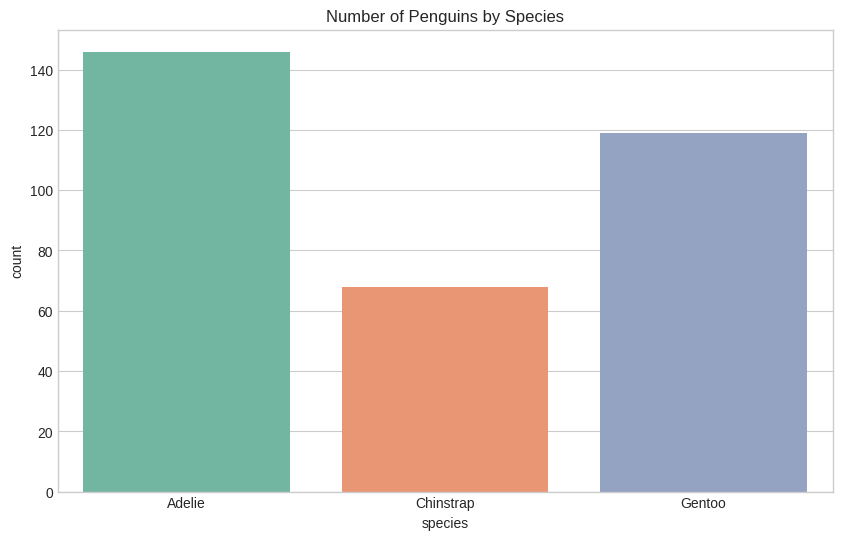

In [ ]:
# ===========================================
# LIVE CODING: Basic Count Plot
# ===========================================
# Create a count plot with:
#   - plt.figure(figsize=(10, 6))
#   - sns.countplot(data=penguins_clean, x='species', palette='Set2')
#   - plt.title('Number of Penguins by Species')
#   - plt.show()


plt.figure(figsize=(10, 6))
sns.countplot(data=penguins_clean, x='species', palette='Set2')
plt.title('Number of Penguins by Species')
plt.show()


## Count Plot with Hue: Two-Way Comparison

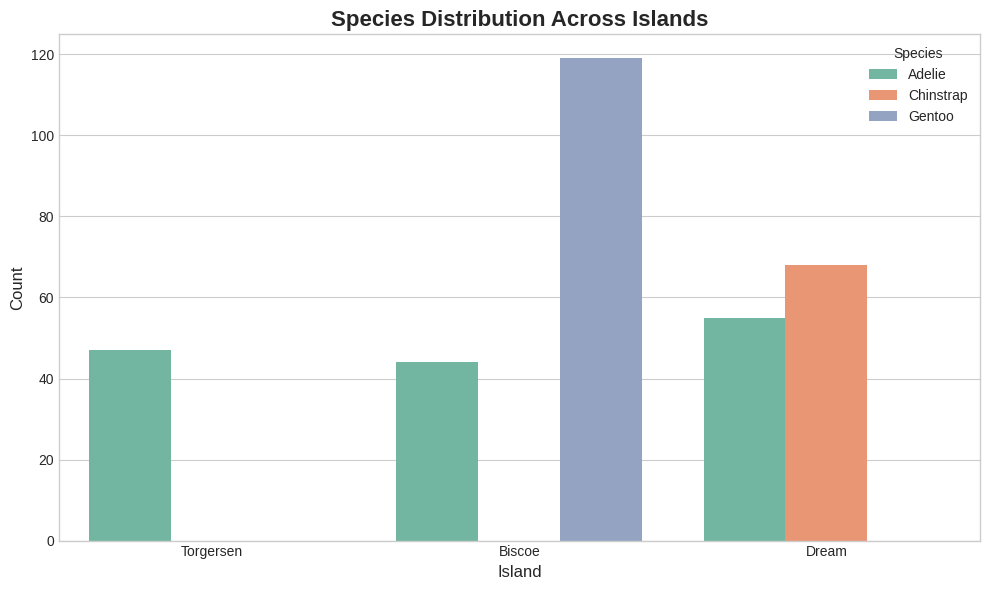

Key observations:
  - Torgersen: Adelie only
  - Dream: Adelie + Chinstrap
  - Biscoe: Adelie + Gentoo (mostly Gentoo)


In [ ]:
# Count plot with hue: Species breakdown by island
plt.figure(figsize=(10, 6))

sns.countplot(data=penguins_clean, x='island', hue='species', palette='Set2')

plt.title('Species Distribution Across Islands', fontsize=16, fontweight='bold')
plt.xlabel('Island', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Species')

plt.tight_layout()
plt.show()

print("Key observations:")
print("  - Torgersen: Adelie only")
print("  - Dream: Adelie + Chinstrap")
print("  - Biscoe: Adelie + Gentoo (mostly Gentoo)")

## Bar Plot: Comparing Means

/tmp/ipython-input-3414140453.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=penguins_clean, x='species', y='body_mass_g', palette='viridis')


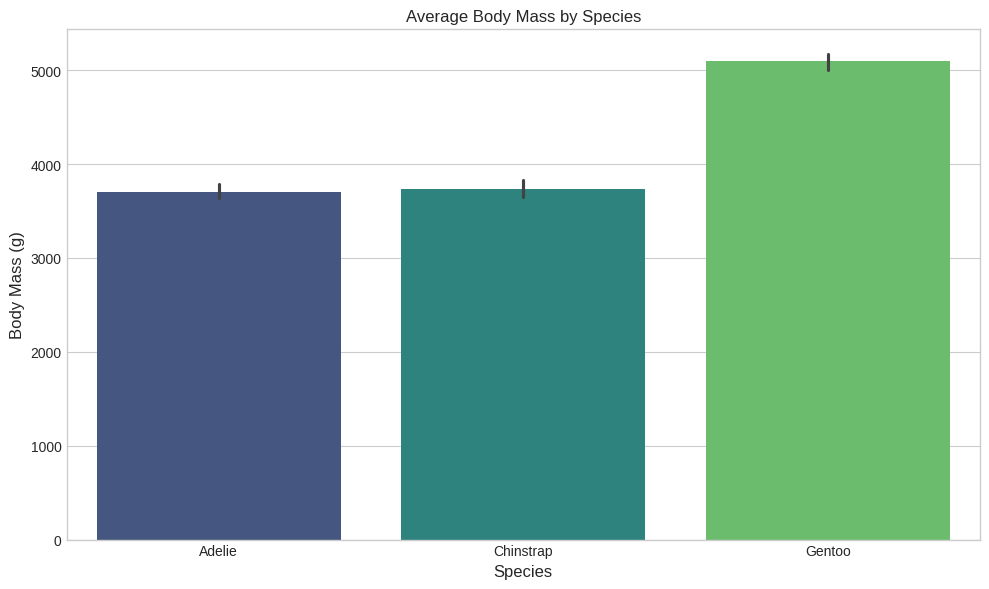

In [ ]:
# ===========================================
# LIVE CODING: Basic Bar Plot
# ===========================================
# Create a bar plot with:
#   - plt.figure(figsize=(10, 6))
#   - sns.barplot(data=penguins_clean, x='species', y='body_mass_g', palette='viridis')
#   - plt.title('Average Body Mass by Species')
#   - plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(data=penguins_clean, x='species', y='body_mass_g', palette='viridis')
plt.title('Average Body Mass by Species')
plt.xlabel ('Species', fontsize = 12)
plt.ylabel('Body Mass (g)', fontsize=12)
plt.tight_layout()
plt.show()

### Understanding Error Bars

The black lines on top of each bar are 95% confidence intervals.
- If error bars **don't overlap** → difference is likely real
- If error bars **overlap a lot** → difference might just be noise

## Grouped Bar Plot: Two-Way Comparison

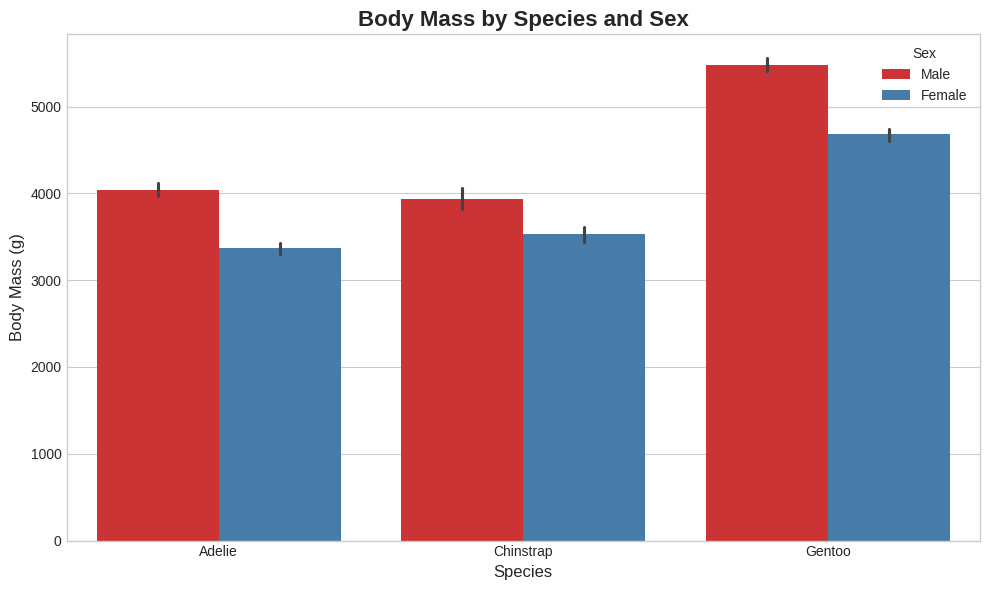

Males are consistently heavier across ALL species.


In [ ]:
# Grouped bar plot: Average body mass by species AND sex
plt.figure(figsize=(10, 6))

sns.barplot(data=penguins_clean, x='species', y='body_mass_g', hue='sex', palette='Set1')

plt.title('Body Mass by Species and Sex', fontsize=16, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)
plt.legend(title='Sex')

plt.tight_layout()
plt.show()

print("Males are consistently heavier across ALL species.")

## Quick Practice: Bar Plots (3 minutes)

**Create a bar plot showing average flipper_length_mm by species, with hue by sex.**

In [ ]:
# calcular porcentajes: como se distribuyen las especies en cada isla

species_by_islands = penguins_clean.groupby('species')['island'].value_counts(normalize=True).unstack(fill_value=0)*100
print('Percentage of species per island')
print(species_by_islands.round(1))


Percentage of species per island
island     Biscoe  Dream  Torgersen
species                            
Adelie       30.1   37.7       32.2
Chinstrap     0.0  100.0        0.0
Gentoo      100.0    0.0        0.0


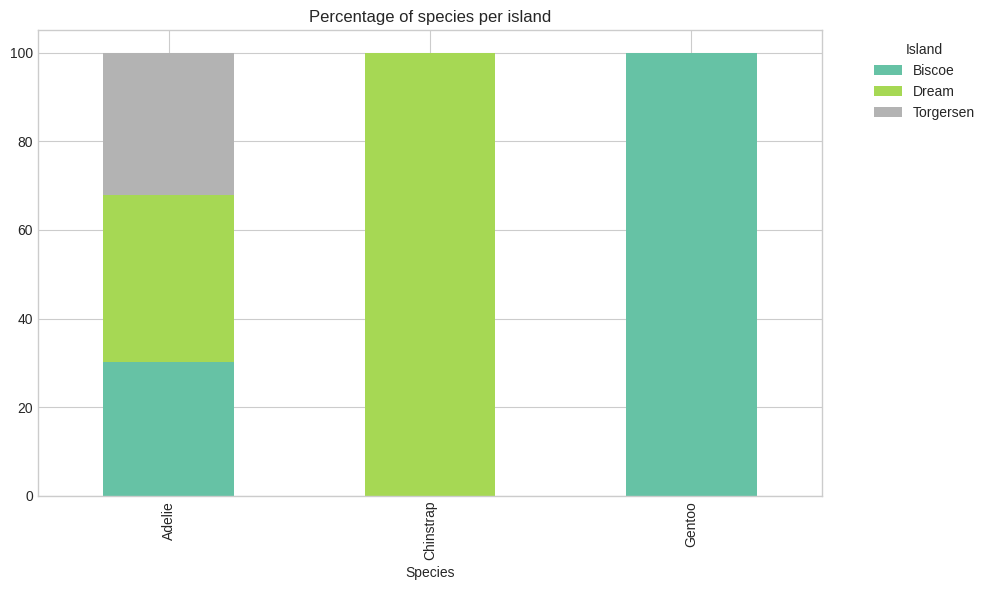

In [ ]:
species_by_islands.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Percentage of species per island')
plt.xlabel('Species')

plt.legend(title='Island', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

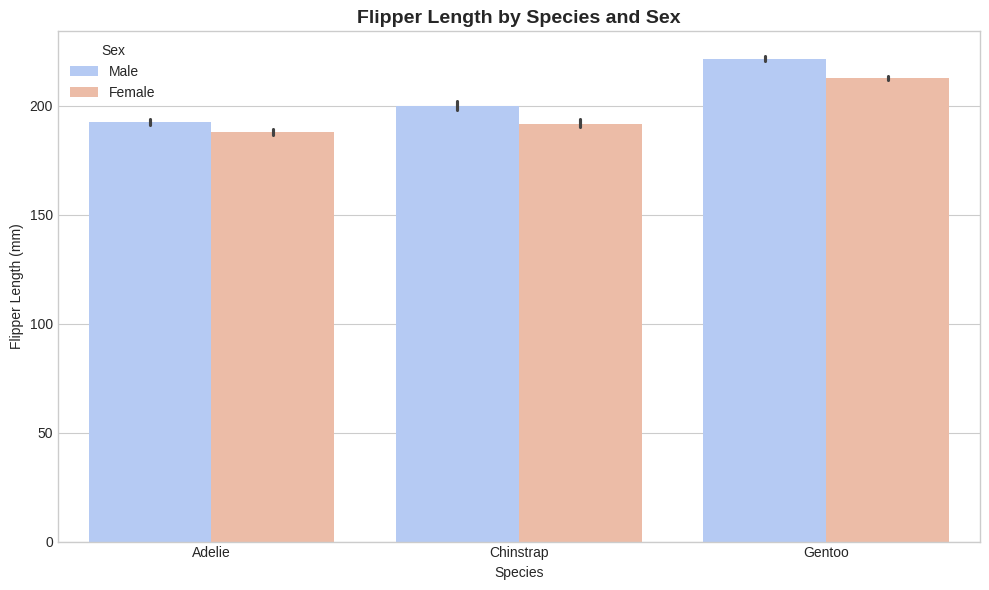

Same pattern as body mass - males have longer flippers across ALL species.


In [ ]:
# EXCERCISE: Crear un bar plot showing average fliper_lengh_mm by species, with hueb by sex
plt.figure(figsize=(10, 6))

sns.barplot(data=penguins_clean, x='species', y='flipper_length_mm',
            hue='sex', palette='coolwarm')

plt.title('Flipper Length by Species and Sex', fontsize=14, fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Flipper Length (mm)')
plt.legend(title='Sex')

plt.tight_layout()
plt.show()

print("Same pattern as body mass - males have longer flippers across ALL species.")

---

## BREAK 2 (10 Minutes)

### What we've covered:
- Histograms with hue to compare distributions
- Count plots for categorical frequencies
- Bar plots for comparing means with confidence intervals

### Coming up after break:
- **Scatter Plots** - Visualizing relationships between variables
- **Simpson's Paradox** - When data lies to you!
- **Pair Plots** - Seeing all relationships at once
- **Mini-Project** - Build a complete dashboard!

---

---

# Part 5: Scatter Plots & Relationships

## "How Do X and Y Relate?"

---

## Basic Scatter: Bill Length vs Bill Depth

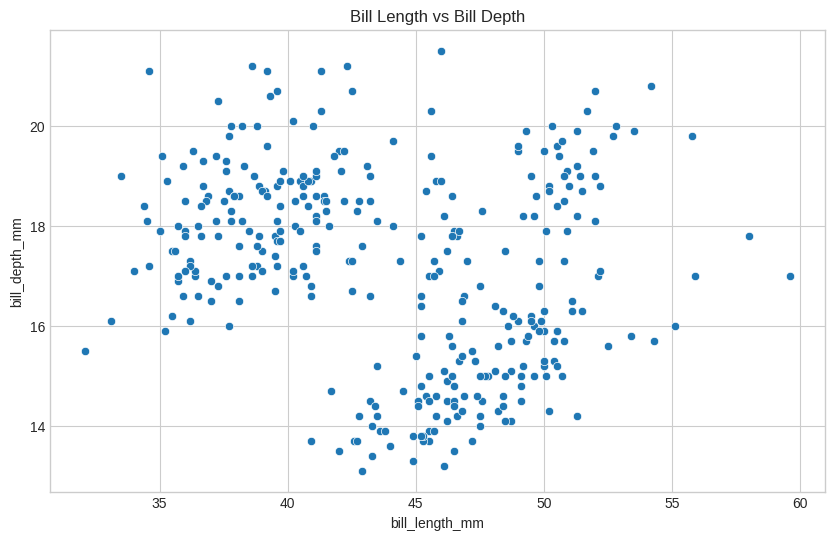

In [ ]:
# ===========================================
# LIVE CODING: Basic Scatter Plot
# ===========================================
# Create a scatter plot with:
#   - plt.figure(figsize=(10, 6))
#   - sns.scatterplot(data=penguins_clean, x='bill_length_mm', y='bill_depth_mm')
#   - plt.title('Bill Length vs Bill Depth')
#   - plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(data=penguins_clean, x='bill_length_mm', y='bill_depth_mm')
plt.title('Bill Length vs Bill Depth')
plt.show()


### Wait... That Looks Wrong?

It looks like there's a **NEGATIVE** correlation - longer bills have shallower depth?

But that doesn't make biological sense! Bigger beaks should be bigger in ALL dimensions...

**Either biology is weird... or this chart is lying to us.**

Let's add species and see what happens.

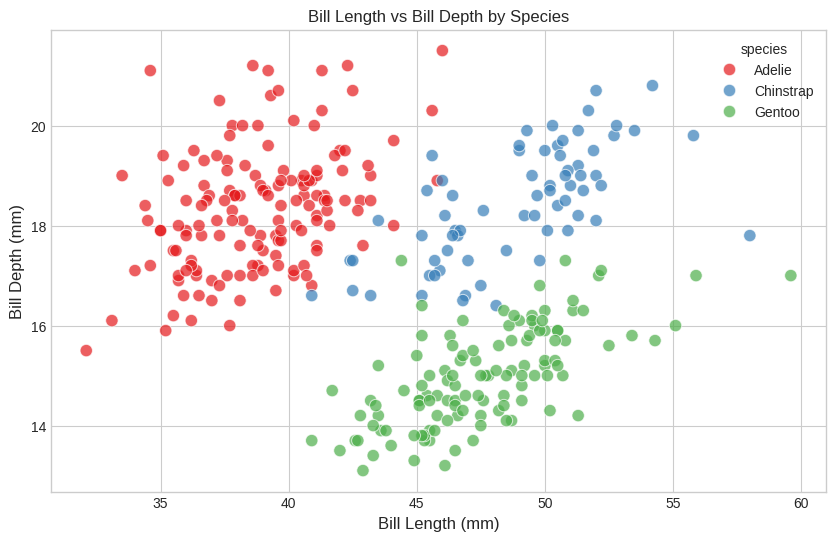

In [ ]:
# ===========================================
# LIVE CODING: The Big Reveal - Add hue by species
# ===========================================
# Add hue='species' to reveal Simpson's Paradox
#   - plt.figure(figsize=(10, 6))
#   - sns.scatterplot(data=penguins_clean, x='bill_length_mm', y='bill_depth_mm',
#                     hue='species', palette='Set1', s=80, alpha=0.7)
#   - plt.title('Bill Length vs Bill Depth by Species')
#   - plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(data=penguins_clean, x='bill_length_mm', y='bill_depth_mm',
                     hue='species', palette='Set1', s=80, alpha=0.7)
plt.title('Bill Length vs Bill Depth by Species')
plt.xlabel('Bill Length (mm)', fontsize=12)
plt.ylabel('Bill Depth (mm)', fontsize=12)
plt.show()



## Simpson's Paradox: When Data Lies

```
WHAT JUST HAPPENED?

    WITHIN each species: Positive correlation (longer = deeper)
    ACROSS all penguins: Negative correlation (longer = shallower)
    
    WHY?
    - Gentoo have LONG bills but SHALLOW depth (bottom-right)
    - Adelie have SHORT bills but DEEP depth (upper-left)
    - Mixing them together reverses the pattern!
    
    THE LESSON:
    Aggregate data can LIE. Always ask:
    "Am I mixing groups that should be analyzed separately?"
```

## Multi-Dimensional Scatter: Using Size and Style

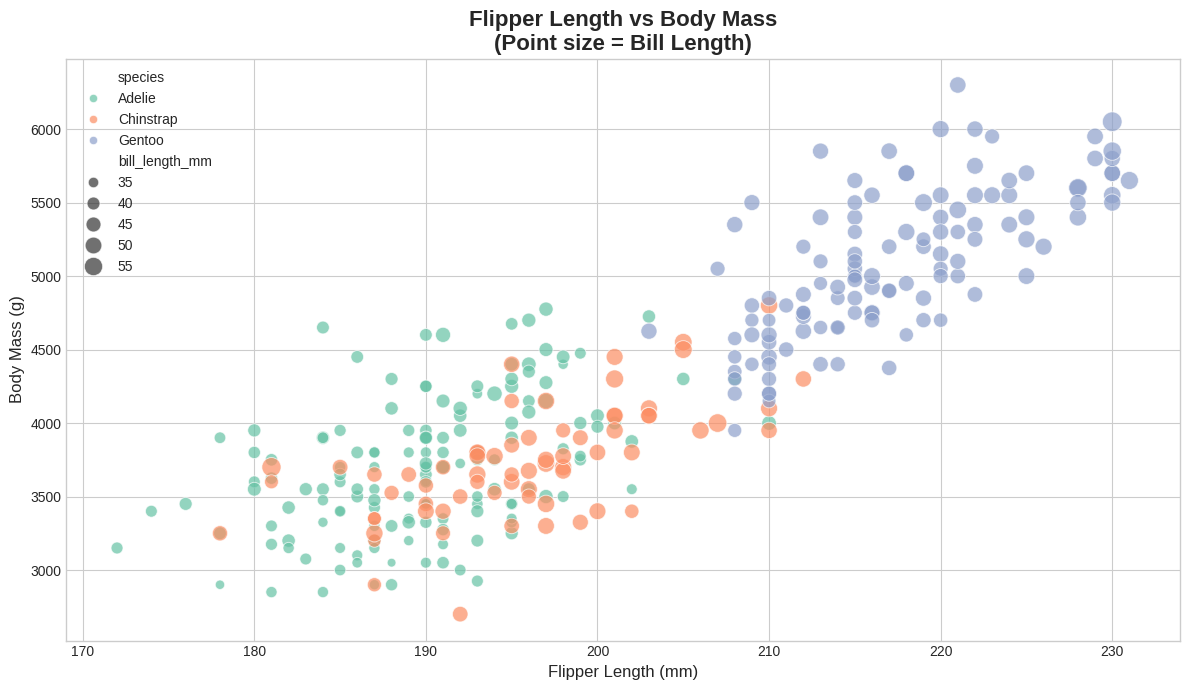

Four variables in one plot: X, Y, Color, and Size!


In [ ]:
# Encode FOUR variables: x, y, color, size
plt.figure(figsize=(12, 7))

sns.scatterplot(data=penguins_clean, x='flipper_length_mm', y='body_mass_g',
                hue='species', size='bill_length_mm',
                sizes=(40, 200), alpha=0.7, palette='Set2')

plt.title('Flipper Length vs Body Mass\n(Point size = Bill Length)', fontsize=16, fontweight='bold')
plt.xlabel('Flipper Length (mm)', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)

plt.tight_layout()
plt.show()

print("Four variables in one plot: X, Y, Color, and Size!")

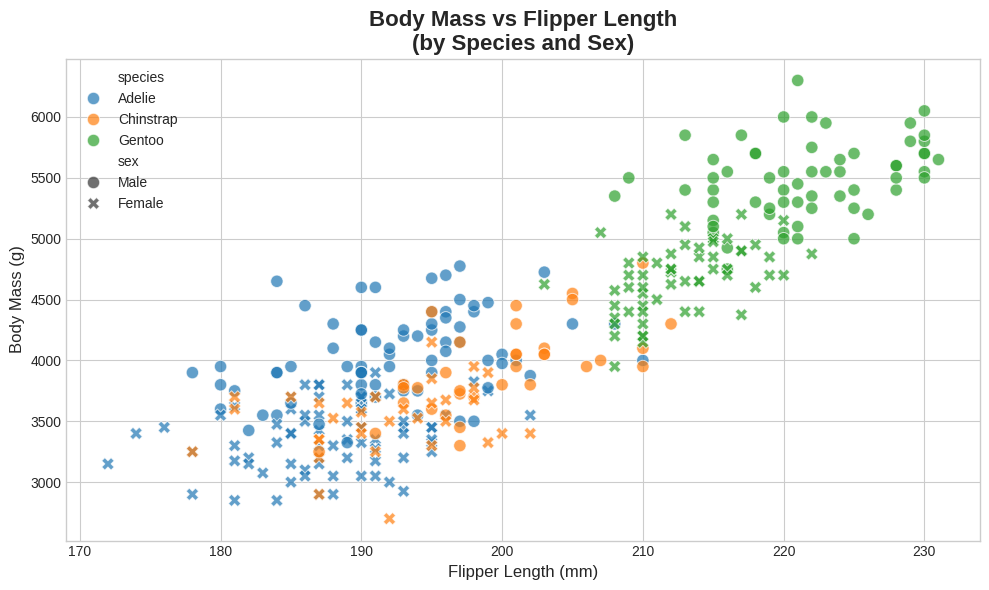

Color = species, Shape = sex


In [ ]:
# Using style for marker shapes
plt.figure(figsize=(10, 6))

sns.scatterplot(data=penguins_clean, x='flipper_length_mm', y='body_mass_g',
                hue='species', style='sex', s=80, alpha=0.7)

plt.title('Body Mass vs Flipper Length\n(by Species and Sex)', fontsize=16, fontweight='bold')
plt.xlabel('Flipper Length (mm)', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)

plt.tight_layout()
plt.show()

print("Color = species, Shape = sex")

## Box Plots: Comparing Distributions

In [ ]:
# ===========================================
# LIVE CODING: Basic Box Plot
# ===========================================
# Create a box plot with:
#   - plt.figure(figsize=(10, 6))
#   - sns.boxplot(data=penguins_clean, x='species', y='body_mass_g', palette='Set2')
#   - plt.title('Body Mass Distribution by Species')
#   - plt.show()



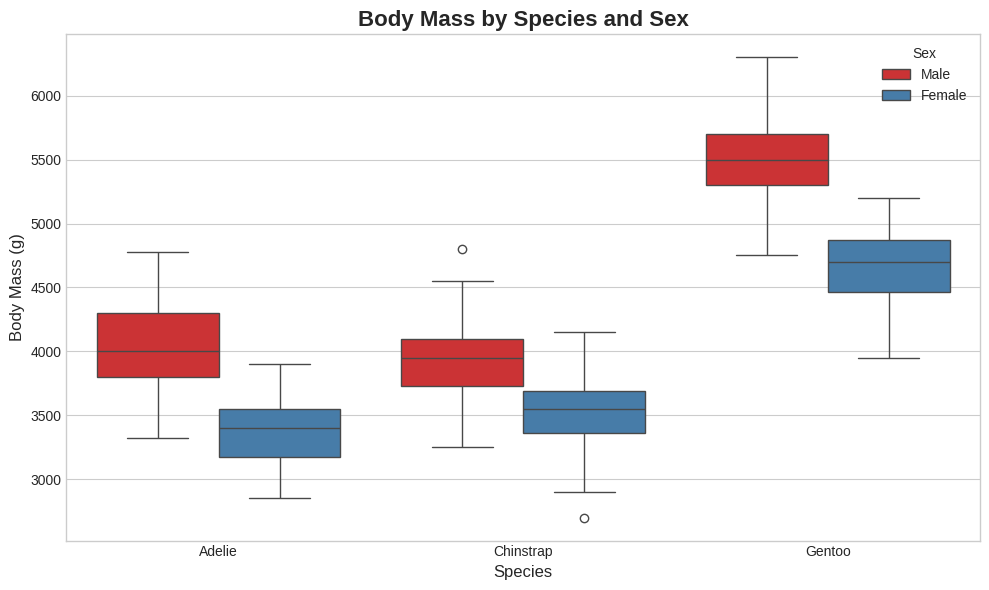

Box plots show the full distribution: median, quartiles, and outliers.


In [ ]:
# Box plot with hue: Body mass by species AND sex
plt.figure(figsize=(10, 6))

sns.boxplot(data=penguins_clean, x='species', y='body_mass_g',
            hue='sex', palette='Set1')

plt.title('Body Mass by Species and Sex', fontsize=16, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)
plt.legend(title='Sex')

plt.tight_layout()
plt.show()

print("Box plots show the full distribution: median, quartiles, and outliers.")

---

# Part 6: Pair Plots - Seeing Everything at Once

## Exploratory Analysis Power Tool

---

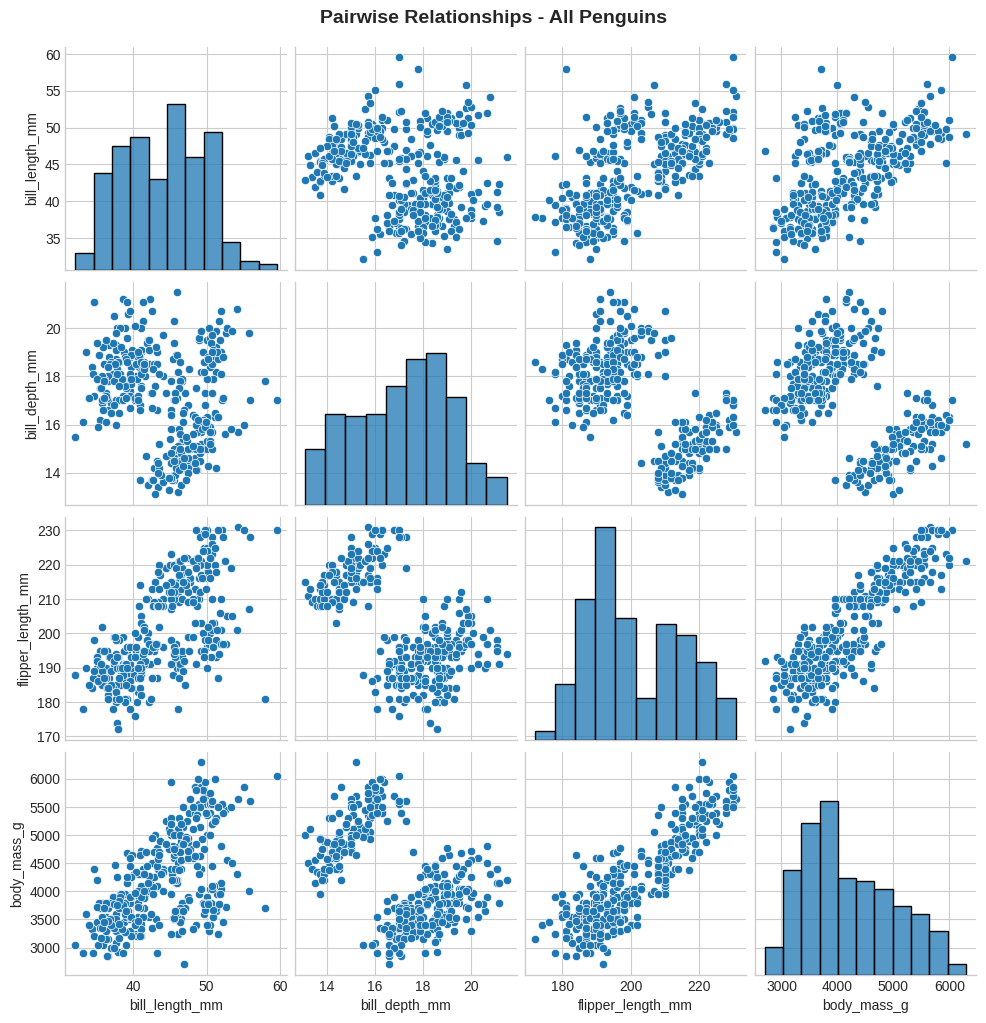

Diagonal = distributions, Off-diagonal = scatter plots


In [ ]:
# Basic pair plot
sns.pairplot(penguins_clean[['bill_length_mm', 'bill_depth_mm',
                              'flipper_length_mm', 'body_mass_g']],
             height=2.5)

plt.suptitle('Pairwise Relationships - All Penguins', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("Diagonal = distributions, Off-diagonal = scatter plots")

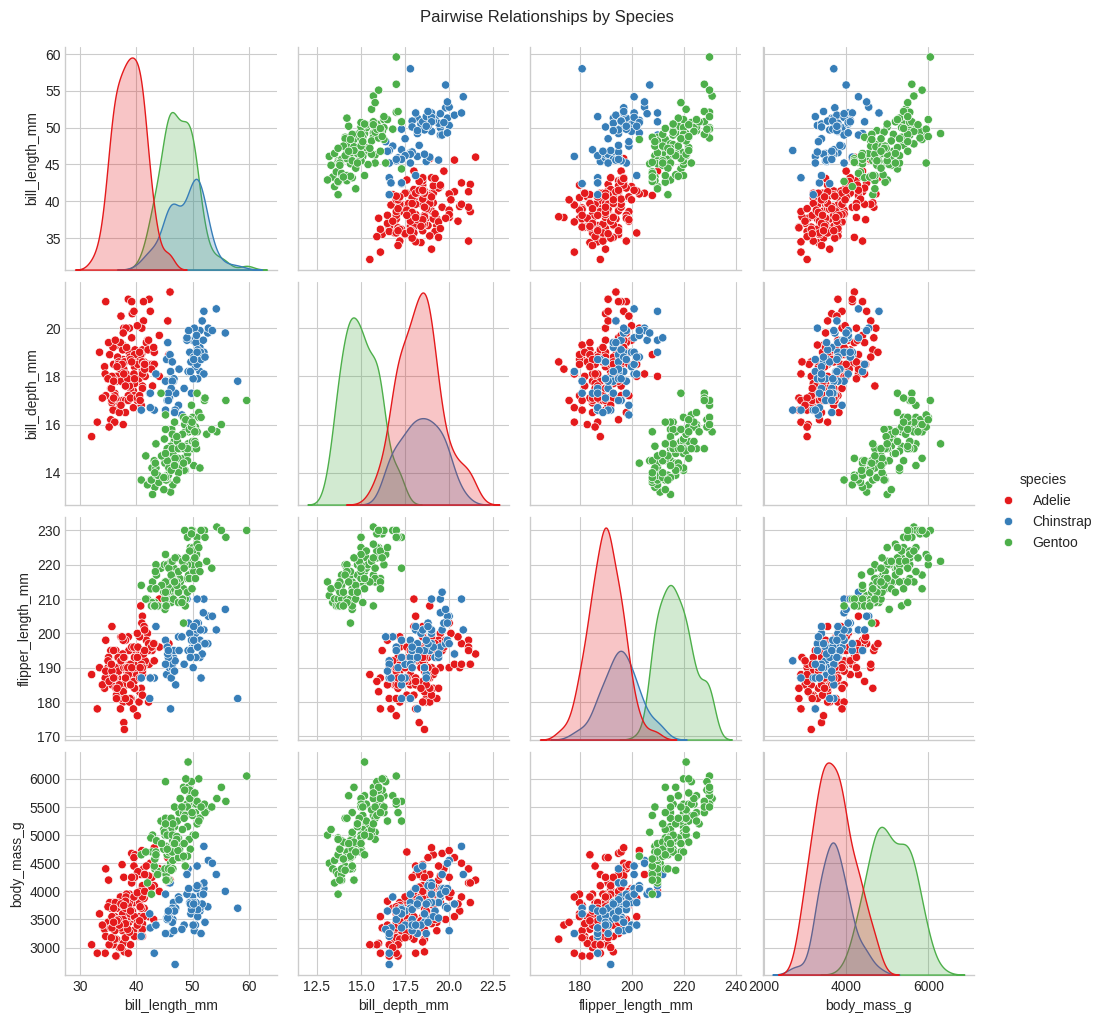

In [ ]:
# ===========================================
# LIVE CODING: Pair plot with hue
# ===========================================
# Add hue to see species patterns:
sns.pairplot(penguins_clean, hue='species',
                  vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
                 diag_kind='kde', height=2.5, palette='Set1')
plt.suptitle('Pairwise Relationships by Species', y=1.02)
plt.show()



## Corner Plot: Less Redundancy

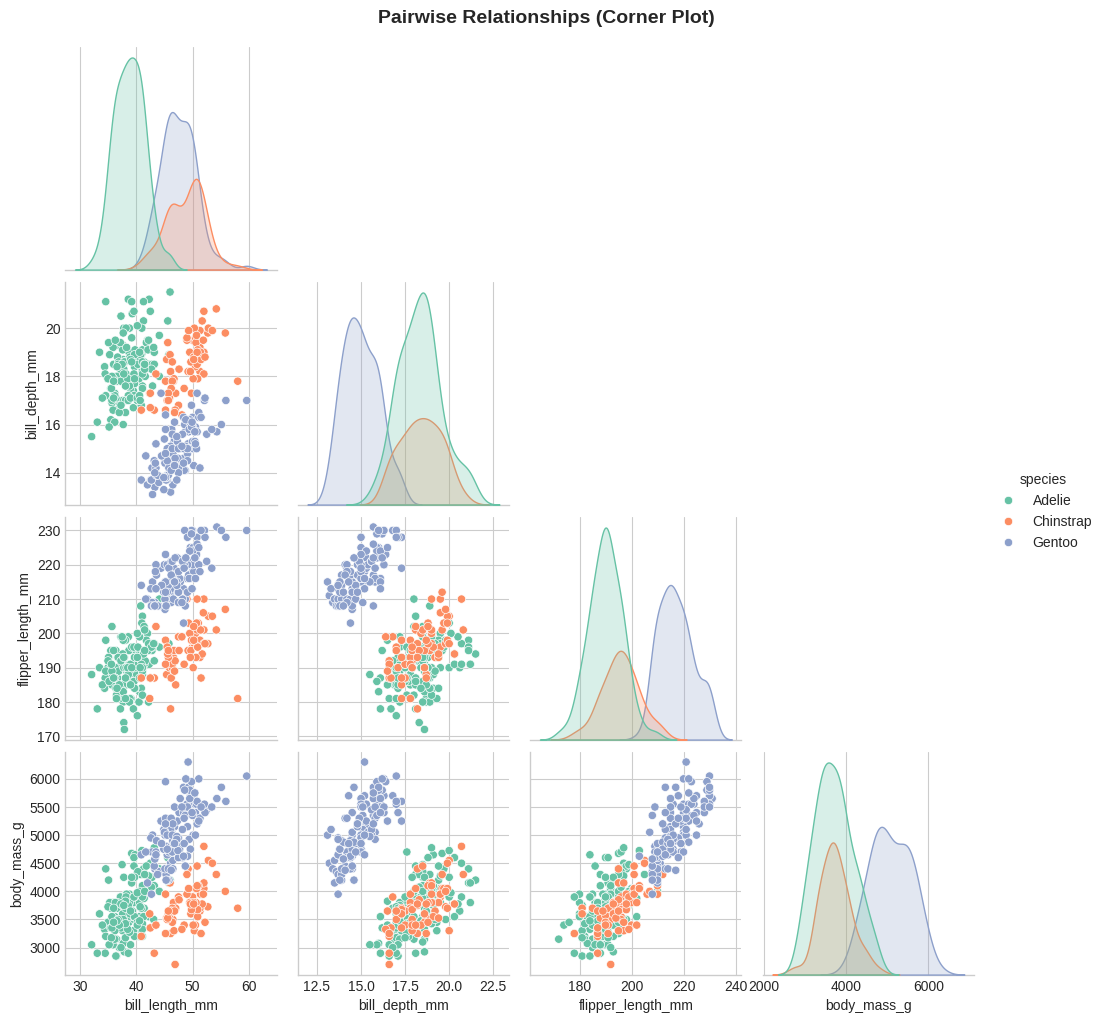

corner=True removes the redundant upper triangle - cleaner for reports.


In [ ]:
# Corner plot - removes redundant upper triangle
sns.pairplot(penguins_clean, hue='species',
             vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
             corner=True, height=2.5, palette='Set2')

plt.suptitle('Pairwise Relationships (Corner Plot)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("corner=True removes the redundant upper triangle - cleaner for reports.")

## PairGrid for More Control

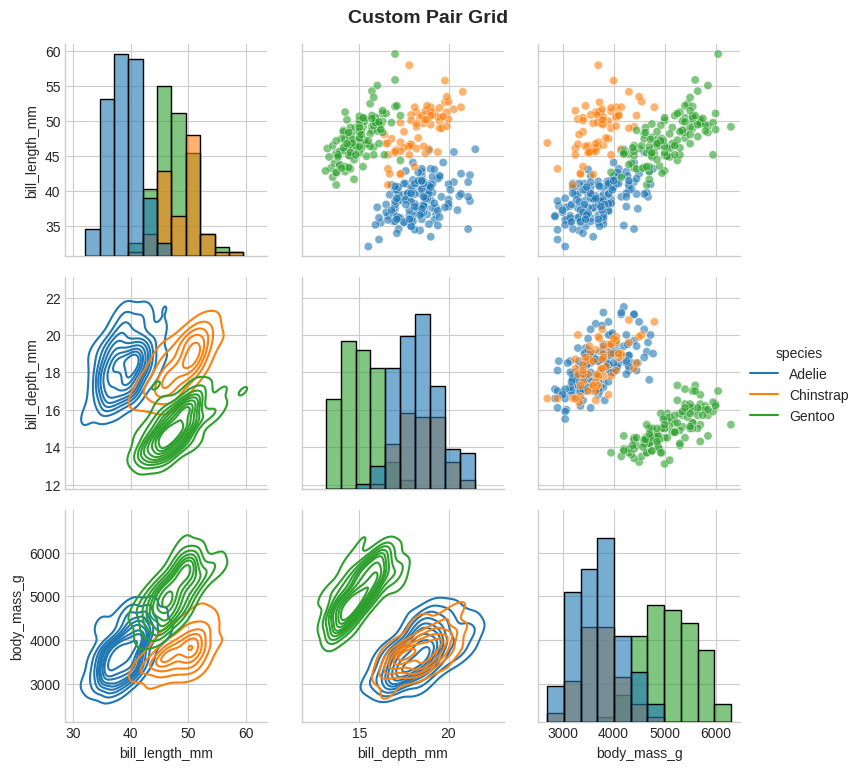

PairGrid: Different plot types in different positions!


In [ ]:
# PairGrid - full control over each section
g = sns.PairGrid(penguins_clean, hue='species',
                 vars=['bill_length_mm', 'bill_depth_mm', 'body_mass_g'])

g.map_diag(sns.histplot, alpha=0.6)      # Histograms on diagonal
g.map_upper(sns.scatterplot, alpha=0.6)  # Scatter on upper triangle
g.map_lower(sns.kdeplot)                 # KDE contours on lower triangle

g.add_legend()
plt.suptitle('Custom Pair Grid', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("PairGrid: Different plot types in different positions!")

---

# Part 7: Mini-Project - Penguin Research Dashboard

## Put It All Together

---

## Your Task (15 minutes)

```
CREATE A 4-PANEL DASHBOARD:

    1. TOP-LEFT: Count plot of species by island
       (Shows species distribution across islands)
    
    2. TOP-RIGHT: Box plot of body_mass_g by species
       (Compares size across species)
       
    3. BOTTOM-LEFT: Box plot of flipper_length_mm by species, hue by sex
       (Shows sexual dimorphism)
       
    4. BOTTOM-RIGHT: Scatter plot of bill_length vs bill_depth, hue by species
       (Shows relationship and Simpson's Paradox!)
    
    
    HINTS:
    - Use fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    - Access subplots with axes[row, col]
    - Use plt.suptitle() for an overall title
    - Don't forget plt.tight_layout()
```

## Solution (by Iosi)

/tmp/ipython-input-636129707.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x='species', y='body_mass_g',


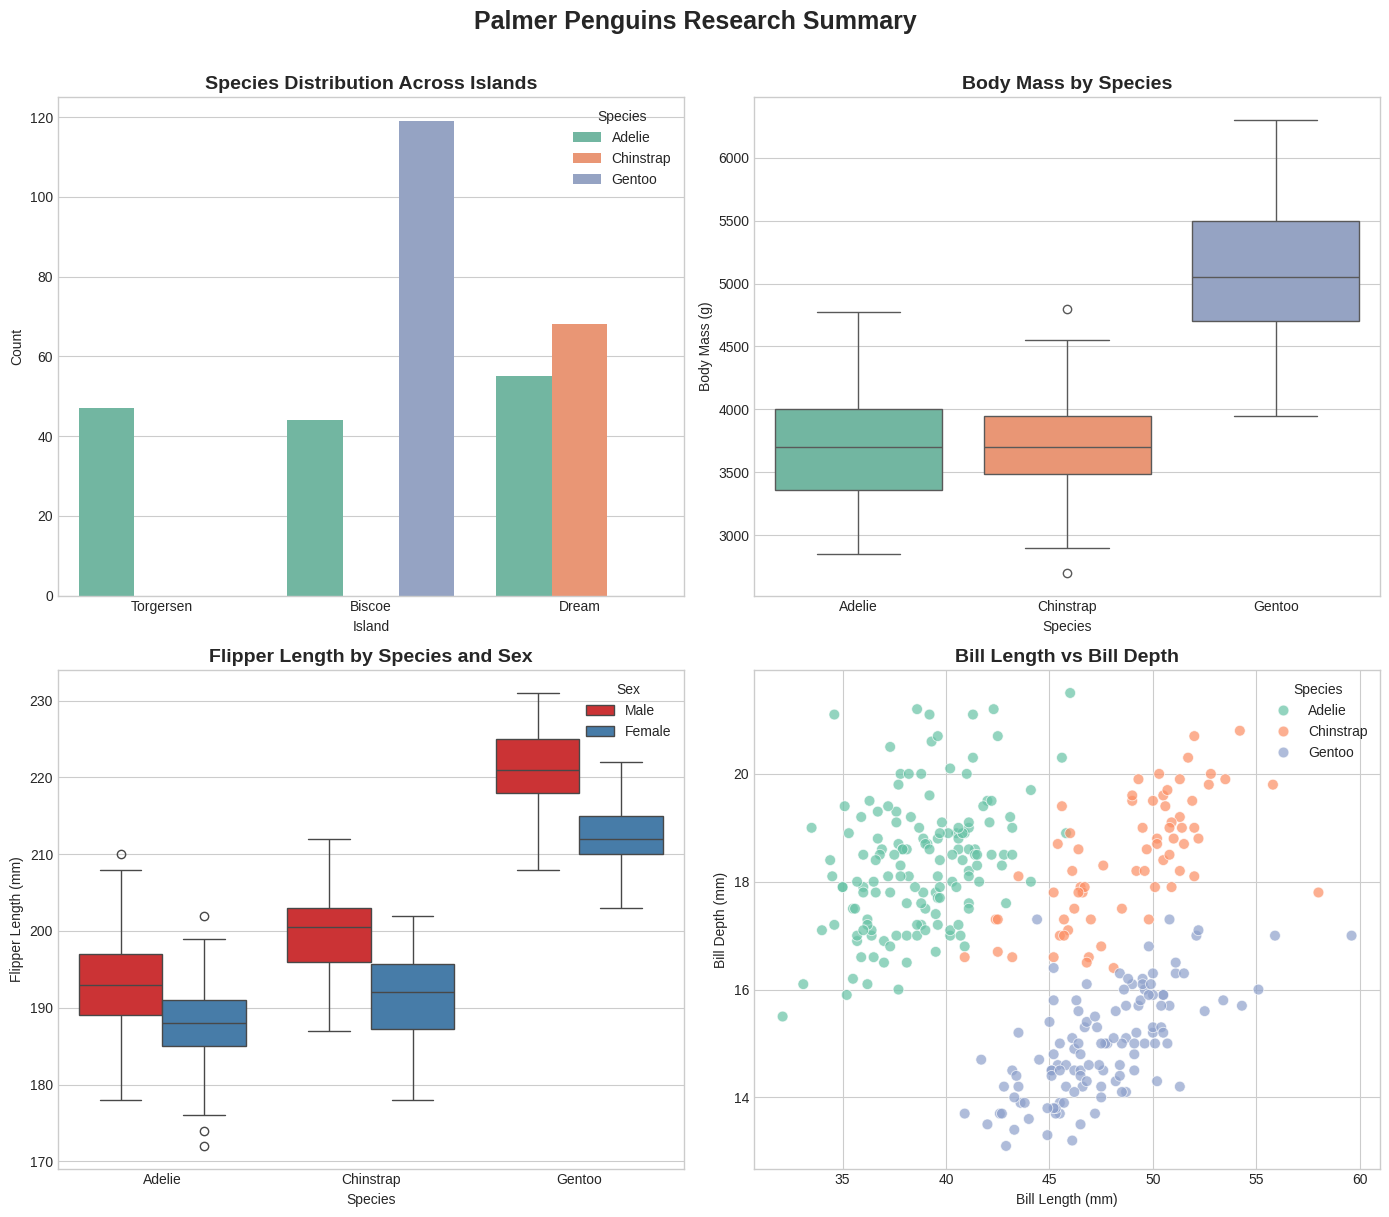

Key findings:
  1. Species have distinct geographic preferences
  2. Gentoo are significantly larger than other species
  3. Sexual dimorphism present in all species (males larger)
  4. Bill shape differs markedly between species


In [ ]:
# SOLUTION: Complete Penguin Research Dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. TOP-LEFT: Species distribution across islands
sns.countplot(data=penguins_clean, x='island', hue='species',
              palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Species Distribution Across Islands', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Island')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(title='Species')

# 2. TOP-RIGHT: Body mass comparison
sns.boxplot(data=penguins_clean, x='species', y='body_mass_g',
            palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Body Mass by Species', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Species')
axes[0, 1].set_ylabel('Body Mass (g)')

# 3. BOTTOM-LEFT: Sexual dimorphism
sns.boxplot(data=penguins_clean, x='species', y='flipper_length_mm',
            hue='sex', palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('Flipper Length by Species and Sex', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Species')
axes[1, 0].set_ylabel('Flipper Length (mm)')
axes[1, 0].legend(title='Sex')

# 4. BOTTOM-RIGHT: Bill dimensions (Simpson's Paradox!)
sns.scatterplot(data=penguins_clean, x='bill_length_mm', y='bill_depth_mm',
                hue='species', palette='Set2', s=60, alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Bill Length vs Bill Depth', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Bill Length (mm)')
axes[1, 1].set_ylabel('Bill Depth (mm)')
axes[1, 1].legend(title='Species')

plt.suptitle('Palmer Penguins Research Summary', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Key findings:")
print("  1. Species have distinct geographic preferences")
print("  2. Gentoo are significantly larger than other species")
print("  3. Sexual dimorphism present in all species (males larger)")
print("  4. Bill shape differs markedly between species")

## Saving Your Dashboard

/tmp/ipython-input-1036812339.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x='species', y='body_mass_g', palette='Set2', ax=axes[0, 1])


Dashboard saved as 'penguin_dashboard.png'!


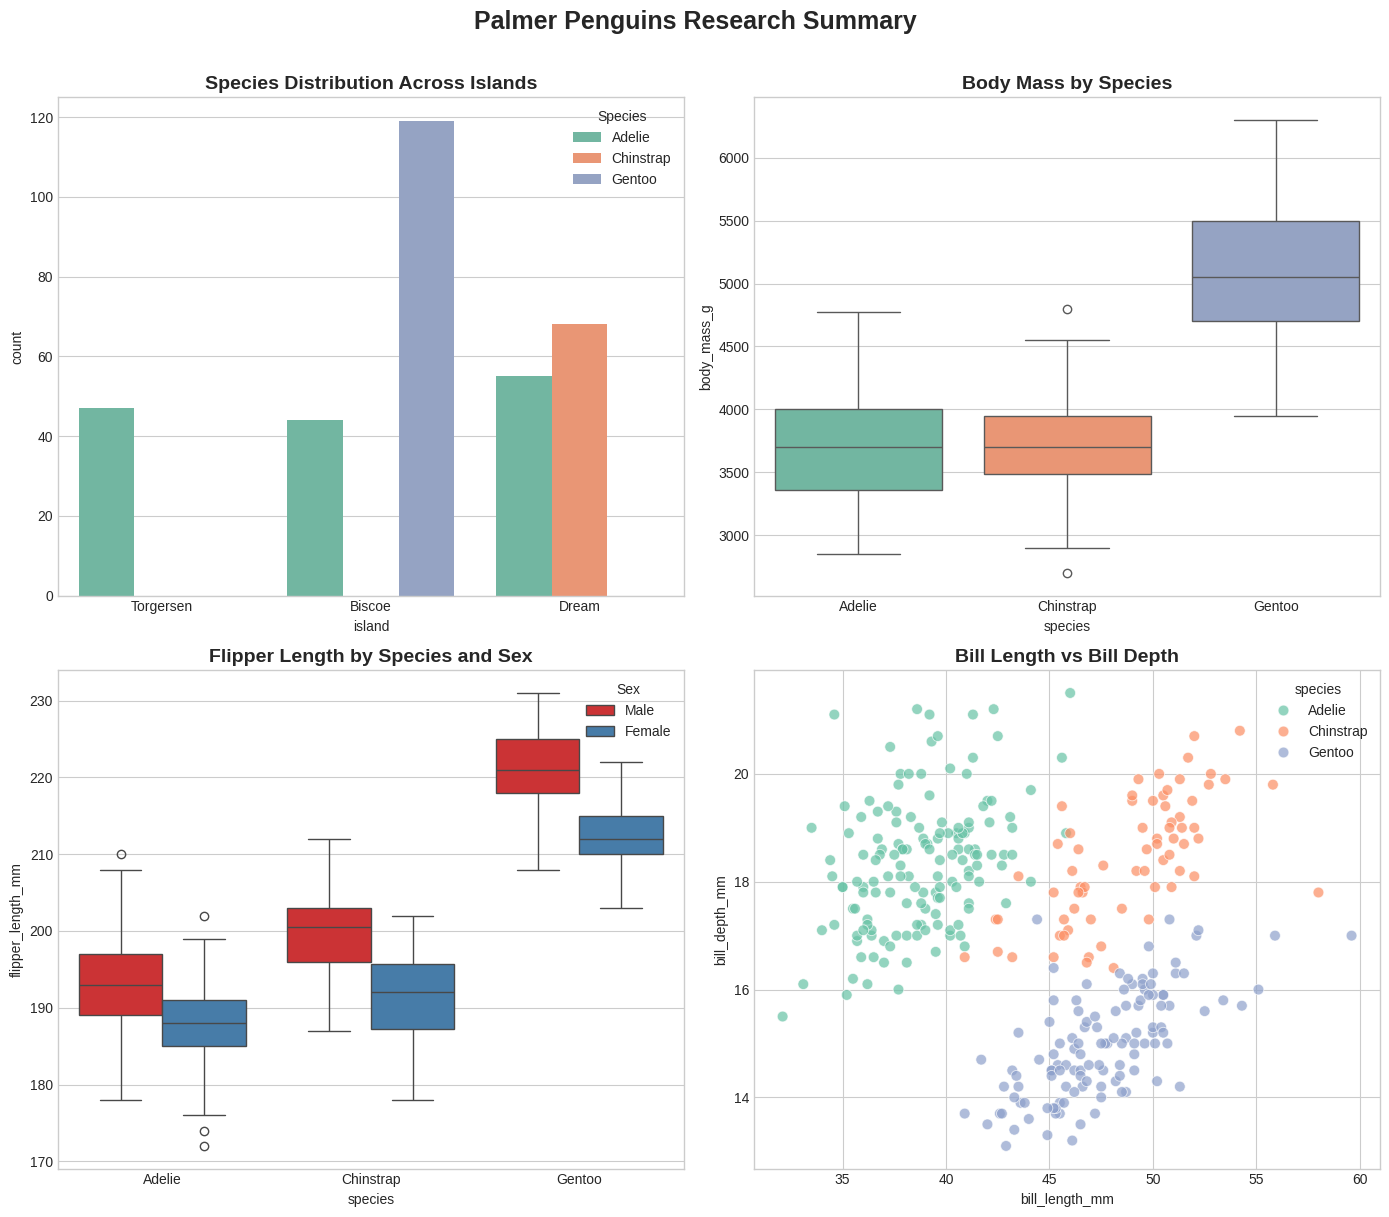

In [ ]:
# Save the dashboard as a high-resolution image
# (Recreate and save)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.countplot(data=penguins_clean, x='island', hue='species', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Species Distribution Across Islands', fontsize=14, fontweight='bold')
axes[0, 0].legend(title='Species')

sns.boxplot(data=penguins_clean, x='species', y='body_mass_g', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Body Mass by Species', fontsize=14, fontweight='bold')

sns.boxplot(data=penguins_clean, x='species', y='flipper_length_mm', hue='sex', palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('Flipper Length by Species and Sex', fontsize=14, fontweight='bold')
axes[1, 0].legend(title='Sex')

sns.scatterplot(data=penguins_clean, x='bill_length_mm', y='bill_depth_mm',
                hue='species', palette='Set2', s=60, alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Bill Length vs Bill Depth', fontsize=14, fontweight='bold')

plt.suptitle('Palmer Penguins Research Summary', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()

# Save with high DPI for publication quality
plt.savefig('penguin_dashboard.png', dpi=300, bbox_inches='tight')
print("Dashboard saved as 'penguin_dashboard.png'!")

plt.show()

---

# Wrap Up

---

## Key Takeaways

```
TODAY'S LESSONS:

    1. QUESTION FIRST, CHART SECOND
       "How is this distributed?" → Histogram
       "How do groups compare?" → Bar/Box plot
       "How do X and Y relate?" → Scatter plot

    2. WEIRD DISTRIBUTIONS = MIXED GROUPS
       When you see bimodal or strange shapes,
       add hue to reveal hidden groups.

    3. AGGREGATE DATA CAN LIE (Simpson's Paradox)
       Always ask: "Am I mixing groups that should
       be analyzed separately?"

    4. PAIR PLOTS = EXPLORATORY SUPERPOWER
       See all relationships at once, then dive deeper.

    5. DASHBOARDS TELL COMPLETE STORIES
       Real analysis = multiple visualizations working together.
```

## Quick Reference: Today's Patterns

```python
# HISTOGRAM - Distribution of continuous variable
sns.histplot(data=df, x='numeric_col', kde=True)
sns.histplot(data=df, x='numeric_col', hue='category', alpha=0.6)

# COUNT PLOT - How many in each category
sns.countplot(data=df, x='category')
sns.countplot(data=df, x='category', hue='subcategory')

# BAR PLOT - Compare means (with confidence intervals)
sns.barplot(data=df, x='category', y='value')
sns.barplot(data=df, x='category', y='value', hue='subcategory')

# SCATTER PLOT - Relationship between two variables
sns.scatterplot(data=df, x='var1', y='var2', hue='category')
sns.scatterplot(data=df, x='var1', y='var2', hue='category', size='numeric', style='sex')

# BOX PLOT - Compare distributions
sns.boxplot(data=df, x='category', y='value')
sns.boxplot(data=df, x='category', y='value', hue='subcategory')

# PAIR PLOT - All relationships at once
sns.pairplot(df, hue='category', diag_kind='kde')
sns.pairplot(df, hue='category', corner=True)  # Less redundant

# DASHBOARD
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
# ... create plots on axes[0,0], axes[0,1], etc.
plt.suptitle('Dashboard Title', fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard.png', dpi=300, bbox_inches='tight')
```

---

# Practice Exercises: Student Mental Health Dataset

## Apply What You Learned to New Data

---

In [ ]:
# Load the Student Mental Health dataset for practice
np.random.seed(42)
n = 101

mental_health = pd.DataFrame({
    'gender': np.random.choice(['Female', 'Male'], n, p=[0.75, 0.25]),
    'age': np.random.choice([18, 19, 20, 21, 22, 23, 24], n,
                            p=[0.15, 0.20, 0.20, 0.15, 0.15, 0.10, 0.05]),
    'course': np.random.choice(
        ['Engineering', 'BCS', 'Law', 'Business', 'Psychology', 'Medicine', 'IT', 'Other'],
        n, p=[0.20, 0.15, 0.10, 0.15, 0.10, 0.08, 0.12, 0.10]),
    'year': np.random.choice(['Year 1', 'Year 2', 'Year 3', 'Year 4'], n,
                             p=[0.30, 0.30, 0.25, 0.15]),
    'cgpa': np.random.choice(
        ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00'],
        n, p=[0.05, 0.10, 0.25, 0.35, 0.25]),
    'depression': np.random.choice(['Yes', 'No'], n, p=[0.35, 0.65]),
    'anxiety': np.random.choice(['Yes', 'No'], n, p=[0.40, 0.60]),
    'panic_attack': np.random.choice(['Yes', 'No'], n, p=[0.30, 0.70]),
    'treatment': np.random.choice(['Yes', 'No'], n, p=[0.10, 0.90])
})

print(f"Mental Health dataset loaded: {mental_health.shape[0]} students")
print(f"Columns: {list(mental_health.columns)}")
mental_health.head()

## Exercise 1: Visualizing the Distribution of CGPA

Create a count plot to visualize the distribution of students' CGPA.

**Hint:** Order the categories properly!

In [ ]:
# Exercise 1: YOUR CODE HERE



## Exercise 2: Comparing Anxiety Levels Across Genders

Create a visualization to compare anxiety rates by gender.

**Hint:** Try a count plot with hue, or calculate percentages.

In [ ]:
# Exercise 2: YOUR CODE HERE



## Exercise 3: Age vs Panic Attacks

Explore if there's any relationship between students' age and the occurrence of panic attacks.

**Hint:** Try a box plot with age on y-axis and panic_attack on x-axis.

In [ ]:
# Exercise 3: YOUR CODE HERE



## Exercise 4: Mental Health Conditions by Year of Study

Create a grouped bar plot showing the COUNT of students with each mental health condition broken down by year.

**Hint:** Use `melt()` to reshape the data first.

In [ ]:
# Exercise 4: YOUR CODE HERE
# Hint:
# conditions = mental_health.melt(id_vars=['year'],
#                                  value_vars=['depression', 'anxiety', 'panic_attack'],
#                                  var_name='condition', value_name='has_condition')
# Then filter for has_condition == 'Yes' and use countplot



## Challenge: Complete Mental Health Dashboard

Create a 2x2 dashboard showing:
1. CGPA distribution
2. Mental health condition rates by gender
3. Age distribution by depression status
4. Year of study vs anxiety (count plot with hue)

In [ ]:
# Challenge: YOUR CODE HERE



---

## Tomorrow Preview: Day 2

- **Correlation Heatmaps** - Visualizing what correlates with what
- **FacetGrid** - Small multiples for comparing subgroups
- **Advanced Customization** - Colors, annotations, professional styling
- **IMDB Dataset Analysis** - Movies, ratings, and genres

---